In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math 

# 1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа)

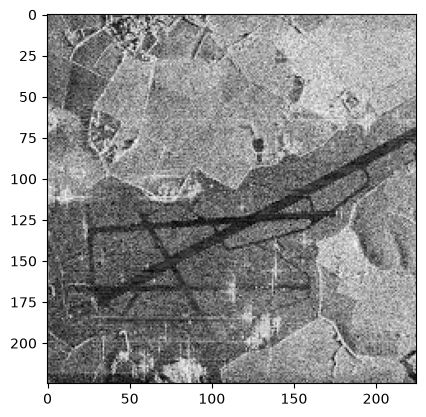

In [77]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

plt.imshow(image_gray, cmap="gray")

In [78]:
image_res = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [79]:
canny = cv2.Canny(image_gray, 150, 350, apertureSize=3)
lines = cv2.HoughLines(canny, 1, np.pi / 180, 130)

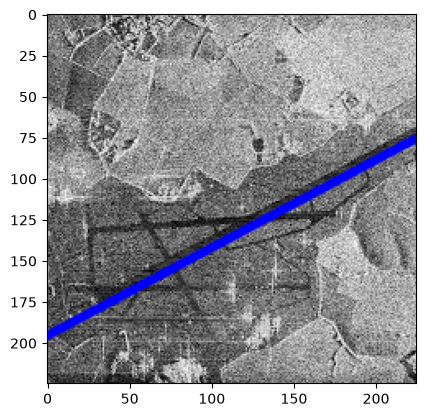

In [80]:
if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(image_res, pt1, pt2, (0, 0 , 255), 3, cv2.LINE_AA)

plt.imshow(image_res)

# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

In [81]:
# Точечная бинаризация
import copy

bin_img = copy.deepcopy(image_gray)
T  = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

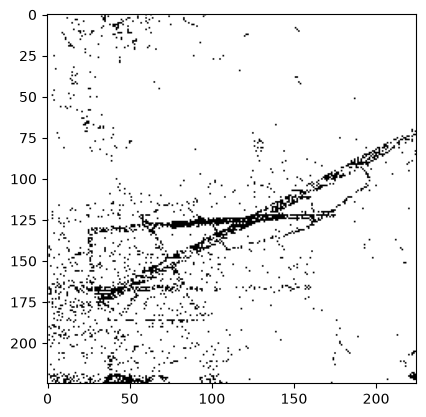

In [82]:
plt.imshow(bin_img, cmap="gray")

In [83]:
# Бинаризация Отсу
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

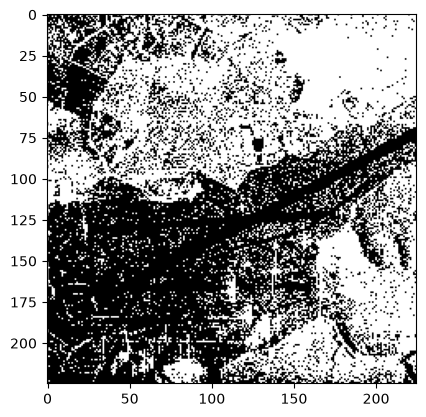

In [84]:
plt.imshow(th2, cmap="gray")

In [87]:
# Адаптивная бинаризация
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,71,21)

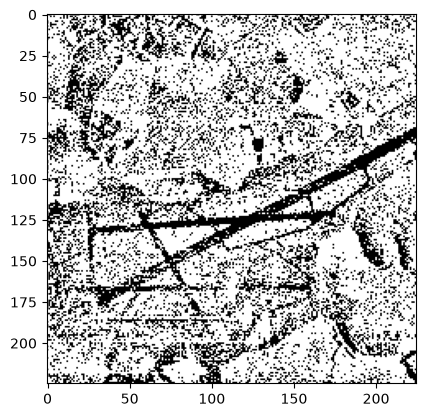

In [86]:
plt.imshow(th3, cmap="gray")

Text(0.5, 1.0, 'Адаптивная бинаризация')

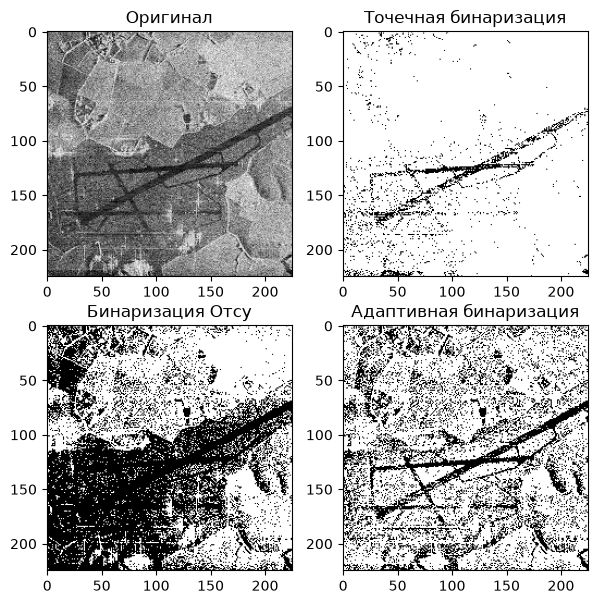

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

axes[0][0].imshow(image_gray, cmap='gray')
axes[0][0].set_title('Оригинал')
axes[0][1].imshow(bin_img, cmap='gray')
axes[0][1].set_title('Точечная бинаризация')
axes[1][0].imshow(th2, cmap='gray')
axes[1][0].set_title('Бинаризация Отсу')
axes[1][1].imshow(th3, cmap='gray')
axes[1][1].set_title('Адаптивная бинаризация')

In [2]:
# Лучший результат показала точечная бинаризация